# Bootstrapping Credit Union Survey

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("wsecu_survey_data.txt", sep ="\t", index_col=0)

In [3]:
df.head()

,id,age,gender,engagement,mem.edu,zip,channel,harm,fair,in.group,authority,purity,account.age,region,public.sector,sustainability,localism,main.focal.value,support.of.focal.value
0,346,56,other,Engaged,2,98503.0,Branch,1.00,1.00,1.00,1.00,1.25,9.951,Thurston,yes,2.333333,2.75,Homelessness,0.000000
1,348,66,female,Highly Engaged,3,98012.0,Branch,5.00,4.75,2.25,3.25,2.25,8.838,W WA Metro,yes,6.000000,5.75,Environment,18.627830
2,349,71,male,Not Engaged,7,98506.0,Branch,3.25,4.25,2.25,3.25,2.75,5.356,Thurston,yes,5.166667,4.50,Hunger/Poverty,28.739986
3,352,66,male,Engaged,7,NaN,Branch,4.25,4.75,4.75,3.25,3.75,9.192,W WA Metro,no,5.500000,4.50,Education,18.055372
4,358,50,male,Highly Engaged,4,98233.0,Branch,2.00,4.50,3.50,4.50,3.25,11.570,W WA Non Metro,yes,2.833333,4.00,Education,4.400921


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2421 entries, 0 to 2420
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      2421 non-null   int64  
 1   age                     2421 non-null   int64  
 2   gender                  2421 non-null   object 
 3   engagement              2421 non-null   object 
 4   mem.edu                 2421 non-null   int64  
 5   zip                     2182 non-null   float64
 6   channel                 2421 non-null   object 
 7   harm                    2421 non-null   float64
 8   fair                    2421 non-null   float64
 9   in.group                2421 non-null   float64
 10  authority               2421 non-null   float64
 11  purity                  2421 non-null   float64
 12  account.age             2421 non-null   float64
 13  region                  2421 non-null   object 
 14  public.sector           2421 non-null   objec

In [5]:
df.shape

(2421, 19)

In [6]:
df.isna().sum()

id                          0
age                         0
gender                      0
engagement                  0
mem.edu                     0
zip                       239
channel                     0
harm                        0
fair                        0
in.group                    0
authority                   0
purity                      0
account.age                 0
region                      0
public.sector               0
sustainability              0
localism                    0
main.focal.value            0
support.of.focal.value      0
dtype: int64

In [7]:
df["zip"].describe()

count     2182.000000
mean     98518.750687
std        359.023960
min      98001.000000
25%      98208.000000
50%      98502.000000
75%      98584.000000
max      99403.000000
Name: zip, dtype: float64

In [8]:
df['zip'] = df.groupby('region')['zip'].transform(lambda x: x.fillna(x.median()))

In [24]:
df['region'].value_counts()

region
W WA Metro        924
Thurston          725
E WA Non Metro    315
W WA Non Metro    276
E WA Metro        181
Name: count, dtype: int64

# Calculate the Progressivism Measure
It's the average of the harm and fair columns minus the average of the other three Moral Foundations Theory dimensions (purity, in.group, authority).

In [9]:
df["progressivism"] = ((df['harm'] + df['fair']) / 2) - ((df['purity'] + df['in.group'] + df['authority']) / 3)

In [10]:
df['progressivism'].describe()

count    2421.000000
mean        0.920487
std         0.975008
min        -2.458333
25%         0.250000
50%         0.791667
75%         1.500000
max         4.375000
Name: progressivism, dtype: float64

# Bootstrap the Mean Progressivism by Region
Use bootstrapping to estimate the mean and 95% confidence interval of progressivism for each region

In [11]:
def bootstrap_means(data, n_sim):
    np.random.seed(77)
    means = []
    for _ in range(n_sim):
        sample = np.random.choice(data, size = len(data), replace = True)
        means.append(np.mean(sample))
    return np.array(means)

In [12]:
regions = df["region"].unique()

In [13]:
bootstrap_summary = []
n_sim = 1000
for region in regions:
    
    mask = df['region'] == region
    region_rows = df.loc[mask]
    region_progressivism = region_rows['progressivism']
    region_data = region_progressivism.dropna()
    
    boot_means = bootstrap_means(region_data, n_sim)
    mean_val = np.mean(boot_means)
    
    lower, upper = np.percentile(boot_means, [2.5, 97.5])

    bootstrap_summary.append({'region': region, 'mean_progressivism': mean_val, 'lower': lower, 'upper': upper})

In [25]:
summary_df = pd.DataFrame(bootstrap_summary)

In [26]:
summary_df

,region,mean_progressivism,lower,upper
0,Thurston,0.959869,0.886034,1.030753
1,W WA Metro,1.101584,1.035375,1.165004
2,W WA Non Metro,0.719736,0.595177,0.835764
3,E WA Non Metro,0.627942,0.528700,0.738796
4,E WA Metro,0.639154,0.534755,0.739480


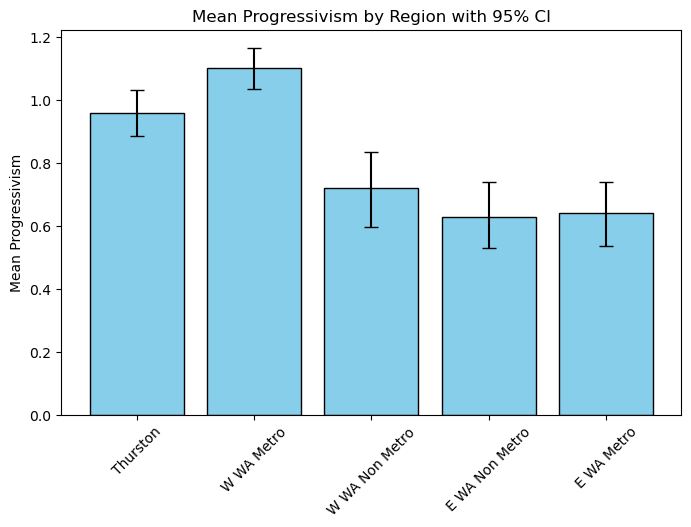

In [27]:
plt.figure(figsize=(8,5))
plt.bar(summary_df['region'], summary_df['mean_progressivism'], 
        yerr=[summary_df['mean_progressivism'] - summary_df['lower'], 
              summary_df['upper'] - summary_df['mean_progressivism']],
        capsize=5, color='skyblue', edgecolor='black')
plt.ylabel("Mean Progressivism")
plt.title("Mean Progressivism by Region with 95% CI")
plt.xticks(rotation=45)
plt.show()


# Bootstrap the Fraction Supporting Education
Estimate the fraction of members in each region whose main.focal.value == "Education".
Use bootstrapping to generate a confidence interval for this proportion.

In [30]:
def bootstrap_proportion(data,value,n):
    np.random.seed(77)
    props = []
    for _ in range(n):
        sample = np.random.choice(data, size = len(data), replace = True)
        prop = np.mean(sample == value)
        props.append(prop)
    return np.array(props)

In [31]:
education_summary = []
for region in regions:
    education_region_data = df.loc[df['region'] == region, 'main.focal.value'].dropna()
    boot_fraction = bootstrap_proportion(data=education_region_data, value="Education", n=1000)


    fraction_mean = np.mean(boot_fraction)
    ed_lower, ed_upper = np.percentile(boot_fraction, [2.5,97.5])

    education_summary.append({'region':region, 'fraction_education':fraction_mean, 'ed_lower':ed_lower, 'ed_upper':ed_upper})
    

In [32]:
edu_df = pd.DataFrame(education_summary)
edu_df

,region,fraction_education,ed_lower,ed_upper
0,Thurston,0.159240,0.135172,0.184828
1,W WA Metro,0.170181,0.146104,0.193750
2,W WA Non Metro,0.144210,0.104982,0.188406
3,E WA Non Metro,0.218137,0.174603,0.266667
4,E WA Metro,0.142967,0.093923,0.193370


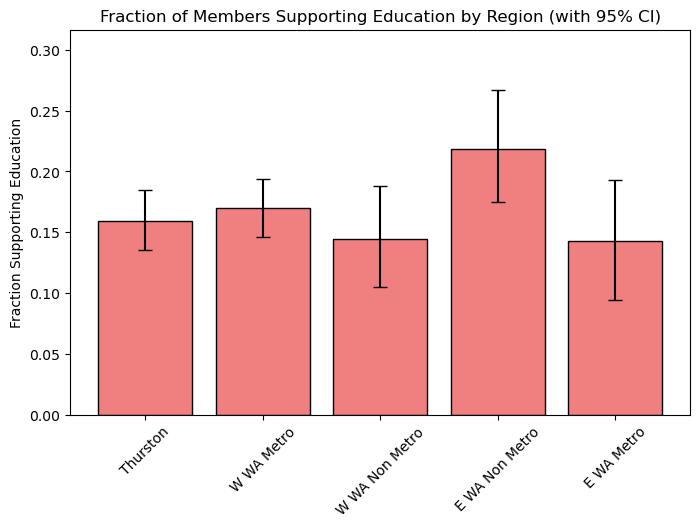

In [33]:
plt.figure(figsize=(8,5))


plt.bar(
    edu_df['region'], 
    edu_df['fraction_education'], 
    yerr=[edu_df['fraction_education'] - edu_df['ed_lower'], 
          edu_df['ed_upper'] - edu_df['fraction_education']],
    capsize=5, 
    color='lightcoral', 
    edgecolor='black'
)

plt.ylabel("Fraction Supporting Education")
plt.title("Fraction of Members Supporting Education by Region (with 95% CI)")
plt.xticks(rotation=45)
plt.ylim(0, edu_df['ed_upper'].max() + 0.05) 
plt.show()


#  Permutation Test: Metro vs. Non-Metro
Perform a permutation test to determine whether the proportion supporting Education differs between these two groups.

In [34]:
group1 = df.query("region == 'W WA Metro' or region == 'Thurston'")
group2 = df.query("region != 'W WA Metro' and region != 'Thurston'")

In [37]:
group1_mean = np.mean(group1['main.focal.value']=='Education')
group2_mean = np.mean(group2['main.focal.value']=='Education')
print(f'group 1 mean -> {group1_mean} and group 2 mean -> {group2_mean}')

group 1 mean -> 0.16555488174651303 and group 2 mean -> 0.17487046632124353


In [38]:
observed_difference = group1_mean - group2_mean
print(f'{observed_difference:.2f}')

-0.01


In [39]:
group1_vals = (group1['main.focal.value'].values == 'Education').astype(int)
group2_vals = (group2['main.focal.value'].values == 'Education').astype(int)

In [40]:
combined = np.concatenate([group1_vals, group2_vals])

In [41]:
n_perm = 10000
perm_diffs = np.zeros(n_perm)

In [43]:
np.random.seed(77)
for i in range(n_perm):
    np.random.shuffle(combined)
    sample_group1 = combined[:len(group1_vals)]
    sample_group2 = combined[len(group1_vals):]
    perm_diffs[i] = np.mean(sample_group1) - np.mean(sample_group2)

In [44]:
p_val = np.mean(np.abs(perm_diffs) >= np.abs(observed_difference))
print(f'p value from the permutation test: {p_val:.4f}')

p value from the permutation test: 0.5941


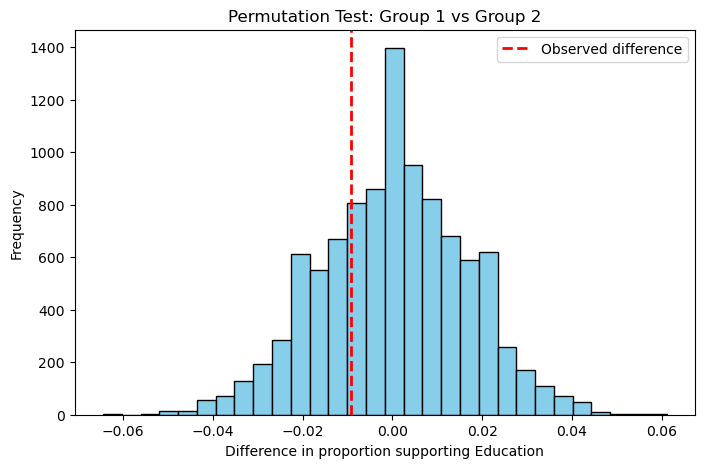

In [45]:
plt.figure(figsize=(8,5))
plt.hist(perm_diffs, bins=30, color='skyblue', edgecolor='black')
plt.axvline(observed_difference, color='red', linestyle='dashed', linewidth=2, label='Observed difference')
plt.xlabel('Difference in proportion supporting Education')
plt.ylabel('Frequency')
plt.title('Permutation Test: Group 1 vs Group 2')
plt.legend()
plt.show()

| Element from OOT | In your example |
|-----------------|----------------|
| 1. Data | Survey data of 2,421 credit union members |
| 2. Test statistic | Difference in proportion of members supporting Education between Group 1 (W WA Metro & Thurston) and Group 2 (W WA Non-metro, E WA Non-metro, and E WA Metro).|
| 3. Observed value or effect | Observed difference = -0.01. |
| 4. Null hypothesis | The proportion supporting Education is the same in Group 1 and Group 2. Any observed difference is due to chance. |
| 5. How you simulate data under the null | Combine all member responses, randomly shuffle them, then split into two groups of the same sizes as the original groups. Compute the difference in proportions for each permutation. Repeat 1,000 times. |
| 6. Description of the reference distribution | A histogram of 1,000 permuted differences in Education support proportions. |
| 7. p-value from comparing observed to simulated | 0.5941 The obsreved difference is likey to happen by chance. We fail to reject the null hypothesis and can say the proportion supporting the Education is similar between the two group. |


# Reflection
The assignment did not take long once I got started, although I spent some time revising bootstrapping beforehand so it felt a bit longer. I started around 4 PM and finished around 8 PM. The hardest part was probably figuring out how to loop through regions and get the progressivism values correctly. It was not conceptually difficult, but I got a bit stuck on the syntax. I am still a little unsure about the bigger purpose of bootstrapping. I understand how it gives a confidence interval, but I am thinking about why we would do it in real life. I am assuming it is to understand the uncertainty in our estimates and to see how reliable our sample statistics are, but I am still a little unsure about its practical use case. I am not confused about how bootstrapping is done, just why it is applied in real-world scenarios.